# Gradient Boosting Regressor

## Problem Statement

In this notebook, we will implement Gradient Boosting Regressor using Python.

Gradient Boosting Regressor is used to predict continuous numerical values.  
It builds multiple weak models step by step and improves prediction errors.

## Dataset Used

We will use the Exercise Dataset from Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

Now we will load the Exercise dataset and convert it into a Pandas DataFrame.

In [2]:
df = sns.load_dataset("exercise")

df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


## Exploratory Data Analysis (EDA)

In this step, we will check:

- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation analysis
- Visualization

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (90, 6)

Missing Values:
Unnamed: 0    0
id            0
diet          0
pulse         0
time          0
kind          0
dtype: int64

Data Types:
Unnamed: 0       int64
id               int64
diet          category
pulse            int64
time          category
kind          category
dtype: object


,Unnamed: 0,id,pulse
count,90.000000,90.000000,90.000000
mean,44.500000,15.500000,99.700000
std,26.124701,8.703932,14.858471
min,0.000000,1.000000,80.000000
25%,22.250000,8.000000,90.250000
50%,44.500000,15.500000,96.000000
75%,66.750000,23.000000,103.000000
max,89.000000,30.000000,150.000000


In [4]:
df.select_dtypes(include=["int64", "float64"]).corr()

,Unnamed: 0,id,pulse
Unnamed: 0,1.000000,0.999506,0.688489
id,0.999506,1.000000,0.679012
pulse,0.688489,0.679012,1.000000


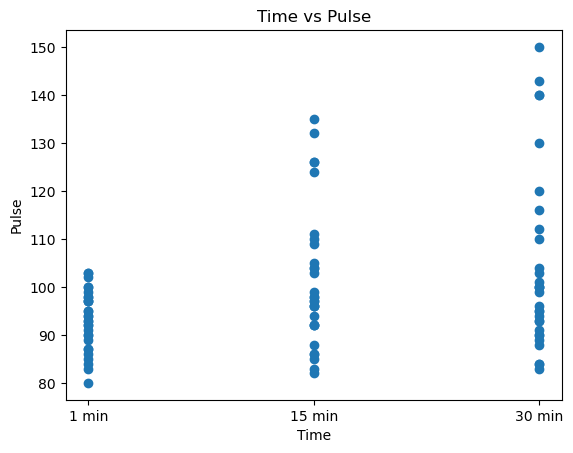

In [5]:
plt.scatter(df["time"], df["pulse"])
plt.xlabel("Time")
plt.ylabel("Pulse")
plt.title("Time vs Pulse")
plt.show()

## Data Preprocessing

In this dataset:

- There are no major missing values
- Some columns are categorical
- Target column is pulse

We will encode categorical columns.

In [6]:
df = df.dropna()

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Unnamed: 0    0
id            0
diet          0
pulse         0
time          0
kind          0
dtype: int64


In [7]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Unnamed: 0,id,pulse,diet_low fat,time_15 min,time_30 min,kind_walking,kind_running
0,0,1,85,True,False,False,False,False
1,1,1,85,True,True,False,False,False
2,2,1,88,True,False,True,False,False
3,3,2,90,True,False,False,False,False
4,4,2,92,True,True,False,False,False


In [8]:
X = df.drop("pulse", axis=1)
y = df["pulse"]

X.head()

,Unnamed: 0,id,diet_low fat,time_15 min,time_30 min,kind_walking,kind_running
0,0,1,True,False,False,False,False
1,1,1,True,True,False,False,False
2,2,1,True,False,True,False,False
3,3,2,True,False,False,False,False
4,4,2,True,True,False,False,False


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (72, 7)
Testing Data: (18, 7)


## Model Building

Now we will create the Gradient Boosting Regressor model.

n_estimators means the number of boosting stages.
learning_rate controls how much each tree contributes.

In [10]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

## Model Training

Now we will train the Gradient Boosting Regressor model using training data.

In [11]:
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Model Prediction

Now we will predict pulse values using testing data.

In [12]:
y_pred = gb_model.predict(X_test)

y_pred[:10]

array([ 98.17715069,  93.04782779, 101.24216834,  99.04413417,
        85.98202246,  97.46816989,  94.17386595, 106.40204232,
        84.38742055,  91.83258696])

## Model Evaluation

We will evaluate the model using:

- MAE
- MSE
- RMSE
- R² Score

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.288145001625028
MSE: 86.71021454287381
RMSE: 9.311831964918278
R2 Score: 0.49329769119143085


## Result Interpretation

Gradient Boosting Regressor improves prediction step by step by learning from previous errors.

A lower RMSE means fewer prediction errors.  
A higher R² score means better model performance.

In [14]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
40,96,98.177151
22,94,93.047828
55,98,101.242168
70,132,99.044134
0,85,85.982022
26,96,97.468170
39,95,94.173866
65,112,106.402042
10,82,84.387421
44,95,91.832587


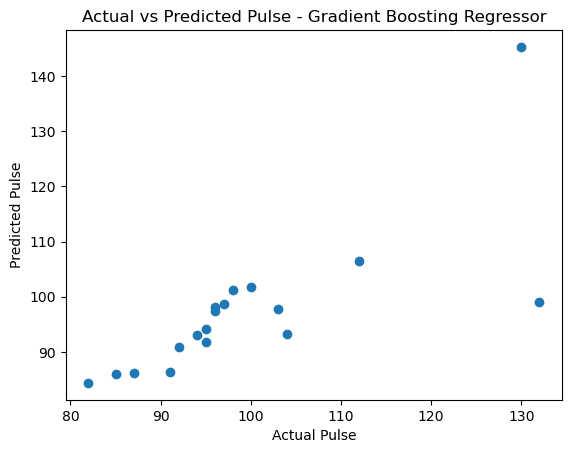

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Pulse")
plt.ylabel("Predicted Pulse")
plt.title("Actual vs Predicted Pulse - Gradient Boosting Regressor")
plt.show()

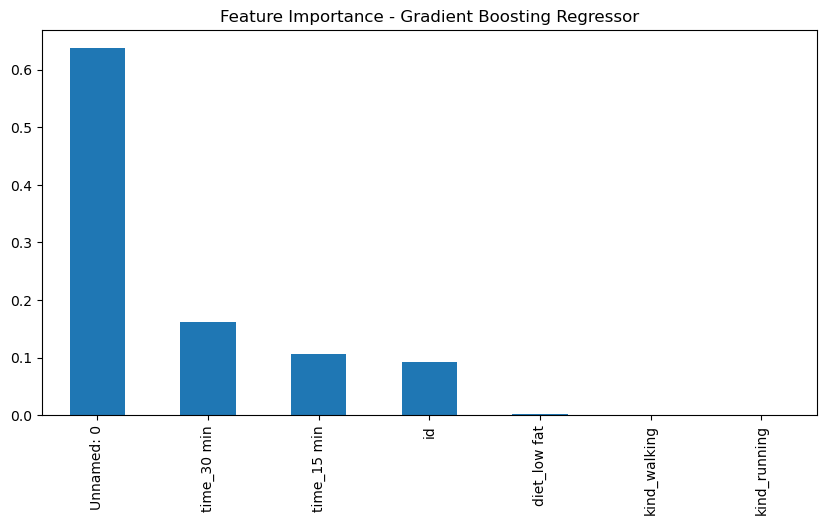

In [16]:
importance = pd.Series(gb_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance - Gradient Boosting Regressor")
plt.show()

## Conclusion

In this notebook, we successfully implemented Gradient Boosting Regressor using Python.

We performed:

- Dataset loading
- Exploratory Data Analysis
- Data preprocessing
- Train-test split
- Model building
- Model training
- Model prediction
- Model evaluation
- Result interpretation

Gradient Boosting Regressor is useful for predicting continuous values and often gives strong performance on structured datasets.